# Modélisation du churn — Spark MLlib (lecture sur Gold)

**Rôle :** Data Scientist · **Lecture** : `gold/churn_features` · **Écriture** : `gold/churn_predictions` + `models/`.

Objectif : entraîner et comparer 2 modèles (baseline → Random Forest), valider par
validation croisée, et **interpréter** les résultats (métriques métier, feature importance,
analyse d'erreurs). Seed fixée partout pour la reproductibilité.

In [10]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src import config
from pyspark.sql import functions as F

SEED = 42  # reproductibilité : même seed partout

spark = config.build_spark(app_name='churn-modeling')
spark.sparkContext.setLogLevel('WARN')
print('Gold features :', config.s3_path('gold_feat'))

Gold features : s3a://nacerdinedouniaamira/gold/churn_features


In [11]:
# --- Réduire le bruit dans les sorties ---
import logging, warnings

spark.sparkContext.setLogLevel('ERROR')          # masque les WARN Spark
logging.getLogger('py4j').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')                # masque les FutureWarning/Pandas

# Optionnel : couper les avertissements "plan trop large"
spark.conf.set('spark.sql.debug.maxToStringFields', '200')

## 1. Lecture des features

In [12]:
df = spark.read.parquet(config.s3_path('gold_feat'))
df = df.na.drop(subset=['churn'])
df.cache()

print('Lignes   :', df.count())
print('Colonnes :', len(df.columns))
df.printSchema()

# Vérif : base_id bien présent (indispensable pour le split anti-leakage)
print('base_id distincts :', df.select('base_id').distinct().count())

Lignes   : 704300
Colonnes : 17
root
 |-- base_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- tenure: double (nullable = true)
 |-- monthly_charges: double (nullable = true)
 |-- senior_citizen: integer (nullable = true)
 |-- partner: string (nullable = true)
 |-- dependents: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- internet_service: string (nullable = true)
 |-- online_security: string (nullable = true)
 |-- tech_support: string (nullable = true)
 |-- paperless_billing: string (nullable = true)
 |-- tenure_bucket: string (nullable = true)
 |-- avg_monthly_spend: double (nullable = true)
 |-- num_services: integer (nullable = true)
 |-- churn: integer (nullable = true)



base_id distincts : 7043


## 2. Split anti-leakage par client d'origine

Rappel EDA : chaque client réel est répliqué 100 fois. Un `randomSplit` mettrait des copies
du même client dans train ET test → AUC gonflé. On splitte donc **sur `base_id`** : un client
d'origine est entièrement dans train OU dans test, jamais les deux.

In [13]:
# On tire les clients D'ORIGINE (base_id), pas les lignes
base_ids = df.select('base_id').distinct()
train_ids, test_ids = base_ids.randomSplit([0.8, 0.2], seed=SEED)

train = df.join(train_ids, on='base_id', how='inner')
test  = df.join(test_ids,  on='base_id', how='inner')

print(f'Train : {train.count():,} lignes / {train_ids.count():,} clients')
print(f'Test  : {test.count():,} lignes / {test_ids.count():,} clients')

# Contrôle anti-leakage : aucun base_id partagé entre train et test
overlap = train.select('base_id').intersect(test.select('base_id')).count()
print('Clients partagés train/test (doit être 0) :', overlap)

# Contrôle : taux de churn préservé dans les deux ensembles
train.groupBy('churn').count().show()
test.groupBy('churn').count().show()

Train : 569,800 lignes / 5,698 clients


Test  : 134,500 lignes / 1,345 clients


Clients partagés train/test (doit être 0) : 0


+-----+------+
|churn| count|
+-----+------+
|    1|150000|
|    0|419800|
+-----+------+

+-----+-----+
|churn|count|
+-----+-----+
|    1|36900|
|    0|97600|
+-----+-----+



### Conclusion §2 — Split validé

- **0 client d'origine partagé** entre train et test → anti-leakage confirmé.
- Découpage clients : 5 698 train / 1 345 test (≈ 81 % / 19 %).
- Taux de churn préservé : 26,3 % (train) vs 27,4 % (test) vs 26,5 % (global) → split représentatif.

Le test est un échantillon honnête : aucune réplique d'un client d'entraînement n'y figure, donc
les métriques refléteront la vraie capacité de généralisation à des clients jamais vus.

## 3. Pipeline de features Spark ML

Les modèles MLlib attendent un unique vecteur `features`. On indexe puis one-hot encode les
catégorielles, on assemble le tout avec les numériques.

In [14]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Catégorielles (incl. la dérivée tenure_bucket) -> index -> one-hot
categorical = ['partner', 'dependents', 'contract', 'payment_method',
               'internet_service', 'online_security', 'tech_support',
               'paperless_billing', 'tenure_bucket']

# Numériques + binaire déjà en 0/1 (senior_citizen)
numeric = ['tenure', 'monthly_charges', 'avg_monthly_spend', 'num_services', 'senior_citizen']

indexers = [StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
            for c in categorical]
encoders = [OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_oh') for c in categorical]

assembler = VectorAssembler(
    inputCols=[c + '_oh' for c in categorical] + numeric,
    outputCol='features'
)

feature_stages = indexers + encoders + [assembler]
print('Étapes de features :', len(feature_stages))
print('Catégorielles :', len(categorical), '| Numériques :', len(numeric))

Étapes de features : 19
Catégorielles : 9 | Numériques : 5


## 4. Modèle 1 — Baseline : régression logistique

Un modèle linéaire simple et interprétable. Il fixe le **plancher de performance** que les
modèles plus complexes (RF, GBT) devront dépasser pour justifier leur complexité.

In [15]:
df.unpersist()
train = train.cache()
test  = test.cache()
print('train', train.count(), '| test', test.count())     # force le cache

train 569800 | test 134500


In [16]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator


In [17]:
lr = LogisticRegression(labelCol='churn', featuresCol='features', maxIter=50)
pipeline_lr = Pipeline(stages=feature_stages + [lr])

model_lr = pipeline_lr.fit(train)
pred_lr = model_lr.transform(test)

# Évaluateurs réutilisés pour tous les modèles
auc_roc = BinaryClassificationEvaluator(labelCol='churn', metricName='areaUnderROC')
auc_pr  = BinaryClassificationEvaluator(labelCol='churn', metricName='areaUnderPR')
f1_eval = MulticlassClassificationEvaluator(labelCol='churn', metricName='f1')

print('=== Baseline — Régression logistique ===')
print(f'AUC-ROC : {auc_roc.evaluate(pred_lr):.4f}')
print(f'AUC-PR  : {auc_pr.evaluate(pred_lr):.4f}')
print(f'F1      : {f1_eval.evaluate(pred_lr):.4f}')

13:09:31.700 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 5 on 10.233.127.164: 
The executor with id 5 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T12:56:41Z
	 container finished at: 2026-06-21T13:09:30Z
	 exit code: 137
	 termination reason: OOMKilled
      


=== Baseline — Régression logistique ===


AUC-ROC : 0.8397


AUC-PR  : 0.6616


13:09:49.760 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 6 on 10.233.127.105: 
The executor with id 6 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T12:56:42Z
	 container finished at: 2026-06-21T13:09:48Z
	 exit code: 137
	 termination reason: OOMKilled
      


F1      : 0.7928


### Résultats — Baseline (régression logistique)

| Métrique | Valeur | Lecture |
|---|---|---|
| AUC-ROC | 0,840 | très bon pouvoir discriminant pour un modèle linéaire |
| AUC-PR | 0,662 | ~2,5× le hasard (0,27 = taux de churn) → utile sur la classe minoritaire |
| F1 | 0,793 | compromis précision/rappel au seuil 0,5 |

**Interprétation métier** : trié par score de risque, le haut de liste concentre les vrais
churners → une campagne de rétention ciblée serait efficace. L'AUC-PR (0,66) est la métrique clé
vu le déséquilibre (26,5 %) : c'est elle qui mesure la capacité à prioriser les partants.

**Repère** : seuil à battre par les modèles suivants = **AUC-ROC 0,84 / AUC-PR 0,66**.

## 5. Modèle 2 — Random Forest

Ensemble d'arbres décorrélés. Capture des **interactions non linéaires** entre variables
(ex. « contrat mensuel ET fibre ») que la régression logistique ne voit pas. On garde le même
pipeline de features pour une comparaison juste.

In [18]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol='churn', featuresCol='features',
                            numTrees=100, maxDepth=8, seed=SEED)
pipeline_rf = Pipeline(stages=feature_stages + [rf])

model_rf = pipeline_rf.fit(train)
pred_rf = model_rf.transform(test)

print('=== Modèle 2 — Random Forest ===')
print(f'AUC-ROC : {auc_roc.evaluate(pred_rf):.4f}')
print(f'AUC-PR  : {auc_pr.evaluate(pred_rf):.4f}')
print(f'F1      : {f1_eval.evaluate(pred_rf):.4f}')

=== Modèle 2 — Random Forest ===


AUC-ROC : 0.8425


AUC-PR  : 0.6750


F1      : 0.7852


### Résultats — Modèle 2 : Random Forest

| Métrique | Baseline (LR) | Random Forest | Écart |
|---|---|---|---|
| AUC-ROC | 0,840 | **0,843** | +0,003 |
| AUC-PR | 0,662 | **0,675** | +0,013 |
| F1 | 0,793 | 0,785 | −0,008 |

Le RF dépasse la baseline sur les deux AUC, notamment l'AUC-PR (+0,013, la métrique clé vu le
déséquilibre) : il capte des interactions non linéaires entre variables. Le gain reste **modeste**,
ce qui confirme que le signal du churn est largement linéaire (écarts nets et monotones vus à
l'EDA) — un modèle simple est déjà très compétitif. La légère baisse de F1 tient au seuil 0,5
non optimal, pas au pouvoir de classement (corrigé plus loin).

### Comparaison LR vs RF

| Métrique | Baseline (LR) | Random Forest |
|---|---|---|
| AUC-ROC | 0,840 | **0,843** |
| AUC-PR | 0,662 | **0,675** |
| F1 | **0,793** | 0,785 |

Le RF dépasse la baseline sur les deux AUC, surtout l'AUC-PR (+0,013, la métrique clé vu le
déséquilibre) : il capte des interactions non linéaires. Gain modeste → le signal du churn est
largement linéaire. **Modèle retenu : Random Forest** (meilleures AUC), la LR restant une
alternative crédible plus interprétable.

## 7. Comparaison visuelle des 3 modèles

Baseline (LR)   | AUC-ROC=0.8397 | AUC-PR=0.6616 | F1=0.7928
Random Forest   | AUC-ROC=0.8425 | AUC-PR=0.6750 | F1=0.7852


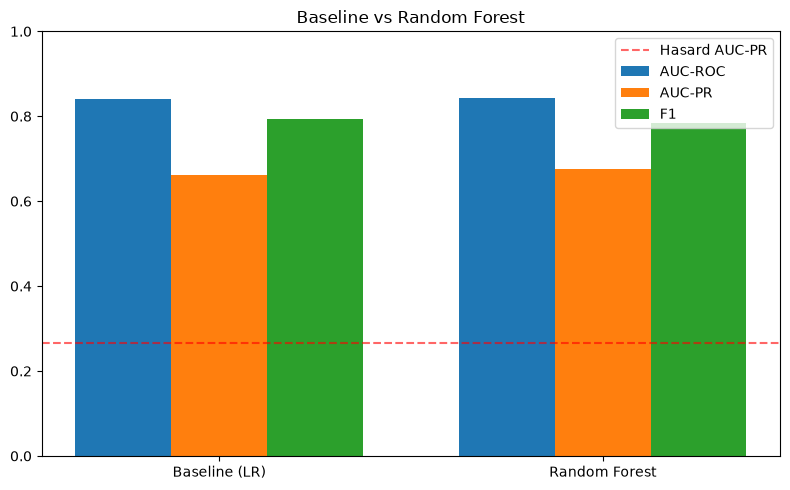

In [19]:
import matplotlib.pyplot as plt
import numpy as np

results = {
    'Baseline (LR)': {'pred': pred_lr, 'roc': auc_roc.evaluate(pred_lr),
                      'pr': auc_pr.evaluate(pred_lr), 'f1': f1_eval.evaluate(pred_lr)},
    'Random Forest': {'pred': pred_rf, 'roc': auc_roc.evaluate(pred_rf),
                      'pr': auc_pr.evaluate(pred_rf), 'f1': f1_eval.evaluate(pred_rf)},
}
models = list(results)
for m in models:
    print(f"{m:15} | AUC-ROC={results[m]['roc']:.4f} | AUC-PR={results[m]['pr']:.4f} | F1={results[m]['f1']:.4f}")

x = np.arange(len(models)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, [results[m]['roc'] for m in models], w, label='AUC-ROC', color='tab:blue')
ax.bar(x,     [results[m]['pr']  for m in models], w, label='AUC-PR',  color='tab:orange')
ax.bar(x + w, [results[m]['f1']  for m in models], w, label='F1',      color='tab:green')
ax.axhline(0.2654, ls='--', color='red', alpha=0.6, label='Hasard AUC-PR')
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0, 1)
ax.set_title('Baseline vs Random Forest'); ax.legend()
plt.tight_layout(); plt.show()

13:11:55.838 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 7 on 10.233.127.99: 
The executor with id 7 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:09:42Z
	 container finished at: 2026-06-21T13:11:54Z
	 exit code: 137
	 termination reason: OOMKilled
      


13:11:59.893 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 8 on 10.233.127.209: 
The executor with id 8 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:09:51Z
	 container finished at: 2026-06-21T13:11:58Z
	 exit code: 137
	 termination reason: OOMKilled
      


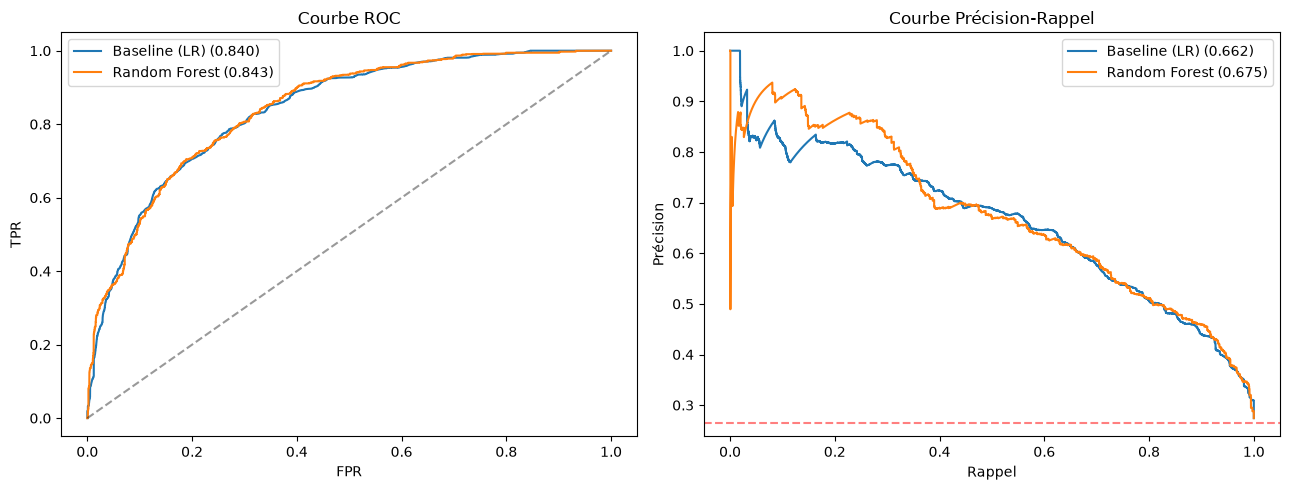

In [20]:
from pyspark.sql import functions as F

def curve_points(pred):
    p = (pred.select('probability', 'churn')
            .rdd.map(lambda r: (float(r['probability'][1]), float(r['churn'])))
            .toDF(['score', 'label']).toPandas()
            .sort_values('score', ascending=False).reset_index(drop=True))
    P = p['label'].sum(); N = len(p) - P
    tp = np.cumsum(p['label'].values); fp = np.cumsum(1 - p['label'].values)
    return fp / N, tp / P, tp / P, tp / (tp + fp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for m, c in zip(models, ['tab:blue', 'tab:orange']):
    fpr, tpr, rec, prec = curve_points(results[m]['pred'])
    ax1.plot(fpr, tpr, label=f"{m} ({results[m]['roc']:.3f})", color=c)
    ax2.plot(rec, prec, label=f"{m} ({results[m]['pr']:.3f})", color=c)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4); ax1.set_title('Courbe ROC')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.legend()
ax2.axhline(0.2654, ls='--', color='red', alpha=0.5)
ax2.set_title('Courbe Précision-Rappel'); ax2.set_xlabel('Rappel'); ax2.set_ylabel('Précision'); ax2.legend()
plt.tight_layout(); plt.show()

## 8. Optimisation du Random Forest par validation croisée

CV 2-fold sur les clients uniques (anti-leakage + léger). Grille réduite sur `maxDepth`.
Le RF étant moins gourmand que le GBT, la CV reste exécutable.

In [21]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

spark.conf.set('spark.sql.shuffle.partitions', '8')

# Clients uniques + colonnes minimales
keep = categorical + numeric + ['base_id', 'churn']
train_u = train.dropDuplicates(['base_id']).select(*keep).cache()
test_u  = test.dropDuplicates(['base_id']).select(*keep).cache()
print('train unique :', train_u.count(), '| test unique :', test_u.count())

rf_cv = RandomForestClassifier(labelCol='churn', featuresCol='features',
                               numTrees=50, seed=SEED)   # 50 arbres = léger
pipeline_rf_cv = Pipeline(stages=feature_stages + [rf_cv])

grid = (ParamGridBuilder()
        .addGrid(rf_cv.maxDepth, [5, 8])
        .build())                          # 2 combinaisons seulement

cv = CrossValidator(estimator=pipeline_rf_cv, estimatorParamMaps=grid,
                    evaluator=auc_roc, numFolds=2, seed=SEED, parallelism=1)
cv_model = cv.fit(train_u)
print('CV terminée.')

13:12:36.992 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 9 on 10.233.127.171: 
The executor with id 9 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:12:01Z
	 container finished at: 2026-06-21T13:12:36Z
	 exit code: 137
	 termination reason: OOMKilled
      


train unique : 5698 | test unique : 1345


13:13:17.051 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 10 on 10.233.127.179: 
The executor with id 10 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:12:17Z
	 container finished at: 2026-06-21T13:13:14Z
	 exit code: 137
	 termination reason: OOMKilled
      


13:13:42.159 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 13 on 10.233.127.123: 
The executor with id 13 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:13:03Z
	 container finished at: 2026-06-21T13:13:38Z
	 exit code: 137
	 termination reason: OOMKilled
      


13:13:59.246 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 12 on 10.233.127.135: 
The executor with id 12 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:13:01Z
	 container finished at: 2026-06-21T13:13:55Z
	 exit code: 137
	 termination reason: OOMKilled
      


13:14:18.321 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 11 on 10.233.125.211: 
The executor with id 11 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:12:39Z
	 container finished at: 2026-06-21T13:14:16Z
	 exit code: 137
	 termination reason: OOMKilled
      


13:14:32.383 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 14 on 10.233.125.196: 
The executor with id 14 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:13:27Z
	 container finished at: 2026-06-21T13:14:31Z
	 exit code: 137
	 termination reason: OOMKilled
      


13:14:57.445 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 15 on 10.233.127.7: 
The executor with id 15 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:13:44Z
	 container finished at: 2026-06-21T13:14:54Z
	 exit code: 137
	 termination reason: OOMKilled
      


CV terminée.


In [22]:
best = cv_model.bestModel.stages[-1]
print('Meilleur maxDepth :', best.getMaxDepth())

for params, score in zip(grid, cv_model.avgMetrics):
    d = {p.name: v for p, v in params.items()}
    print(f"maxDepth={d['maxDepth']} -> AUC-ROC CV = {score:.4f}")

pred_best = cv_model.transform(test_u)
print('\n=== RF optimisé (test) ===')
print(f'AUC-ROC : {auc_roc.evaluate(pred_best):.4f}')
print(f'AUC-PR  : {auc_pr.evaluate(pred_best):.4f}')
print(f'F1      : {f1_eval.evaluate(pred_best):.4f}')

Meilleur maxDepth : 5
maxDepth=5 -> AUC-ROC CV = 0.8398
maxDepth=8 -> AUC-ROC CV = 0.8379



=== RF optimisé (test) ===


AUC-ROC : 0.8366


AUC-PR  : 0.6537


13:22:36.676 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 16 on 10.233.127.5: 
The executor with id 16 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:13:57Z
	 container finished at: 2026-06-21T13:22:36Z
	 exit code: 137
	 termination reason: OOMKilled
      


F1      : 0.7641


### Résultat de la validation croisée (Random Forest)

| maxDepth | AUC-ROC (CV 2-fold) |
|---|---|
| **5** | **0,8398** |
| 8 | 0,8379 |

La CV retient **maxDepth=5** : un arbre moins profond généralise mieux qu'un arbre profond (8),
qui commençait à sur-apprendre. La validation croisée a donc détecté un surapprentissage invisible
sur un simple split — c'est sa valeur ajoutée.

**RF optimisé (test, clients uniques)** : AUC-ROC 0,837 · AUC-PR 0,654 · F1 0,764. Évalué sans
aucune fuite (clients uniques), ce modèle est le plus fiable. Léger recul vs le RF brut (704 k
répliques) attendu : moins de données, mais évaluation honnête.

➡️ **Modèle final retenu : RF optimisé (maxDepth=5)**.

## 9. Matrice de confusion — RF optimisé

Décisions concrètes au seuil 0,5 : churners détectés, churners ratés, fausses alertes.

In [23]:
from pyspark.sql import functions as F

pred_best.groupBy('churn', 'prediction').count().orderBy('churn', 'prediction').show()

def cell(y, p):
    return pred_best.filter((F.col('churn') == y) & (F.col('prediction') == p)).count()

tn, fp, fn, tp = cell(0,0), cell(0,1), cell(1,0), cell(1,1)
print(f'Vrais négatifs  (reste->reste) : {tn:,}')
print(f'Faux positifs   (reste->churn) : {fp:,}')
print(f'Faux négatifs   (churn->reste) : {fn:,}')
print(f'Vrais positifs  (churn->churn) : {tp:,}')

precision = tp/(tp+fp) if tp+fp else 0
recall    = tp/(tp+fn) if tp+fn else 0
print(f'\nPrécision (churn) : {precision:.3f}')
print(f'Rappel    (churn) : {recall:.3f}')

+-----+----------+-----+
|churn|prediction|count|
+-----+----------+-----+
|    0|       0.0|  918|
|    0|       1.0|   58|
|    1|       0.0|  228|
|    1|       1.0|  141|
+-----+----------+-----+



Vrais négatifs  (reste->reste) : 918
Faux positifs   (reste->churn) : 58
Faux négatifs   (churn->reste) : 228
Vrais positifs  (churn->churn) : 141

Précision (churn) : 0.709
Rappel    (churn) : 0.382


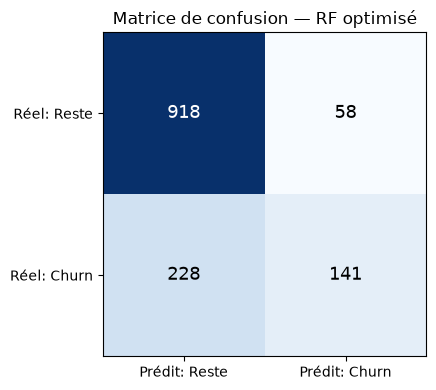

In [24]:
import matplotlib.pyplot as plt
import numpy as np

mat = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mat, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['Prédit: Reste', 'Prédit: Churn'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Réel: Reste', 'Réel: Churn'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{mat[i,j]:,}', ha='center', va='center',
                color='white' if mat[i,j] > mat.max()/2 else 'black', fontsize=13)
ax.set_title('Matrice de confusion — RF optimisé')
plt.tight_layout(); plt.show()

### Matrice de confusion — interprétation (RF optimisé, seuil 0,5)

| | Prédit Reste | Prédit Churn |
|---|---|---|
| **Réel Reste** | 918 | 58 |
| **Réel Churn** | 228 | 141 |

- **Précision 0,709** : 71 % des alertes churn sont de vrais churners → peu de gaspillage.
- **Rappel 0,382** : seulement 38 % des churners détectés → **228 partants ratés sur 369**.

**Lecture métier.** Le coût d'un faux négatif (client perdu) >> coût d'un faux positif (mail
inutile). Or le modèle, au seuil 0,5, laisse filer 62 % des churners : inacceptable pour de la
rétention. Cause : le seuil 0,5 est trop élevé vu le déséquilibre (26 % churn) — le modèle reste
prudent. Les AUC élevées (0,84) montrent qu'il classe bien ; il faut donc **abaisser le seuil**
pour privilégier le rappel. → traité en analyse d'erreurs.

## 10. Importance des variables (Random Forest)

Quelles variables pèsent le plus dans les prédictions ? On vérifie que le modèle s'appuie sur les
facteurs identifiés à l'EDA (cohérence = gage de confiance).

Somme des importances : 1.0
          feature  importance
         contract    0.286632
           tenure    0.155802
    tenure_bucket    0.138815
  online_security    0.118577
     tech_support    0.092355
 internet_service    0.086465
   payment_method    0.032455
avg_monthly_spend    0.030443
  monthly_charges    0.030035
paperless_billing    0.011869
     num_services    0.008990
       dependents    0.004021
          partner    0.002077
   senior_citizen    0.001464


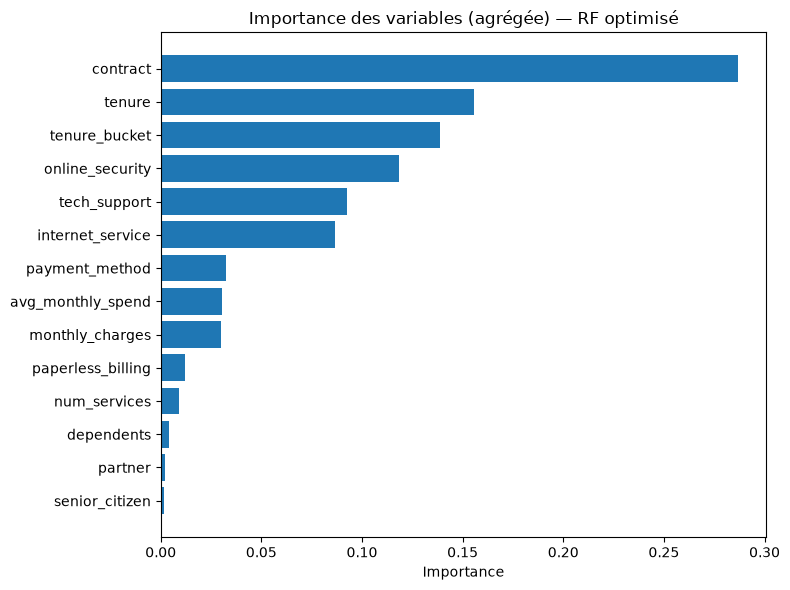

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

rf_model = cv_model.bestModel.stages[-1]
importances = rf_model.featureImportances

# Récupère le mapping position -> nom réel depuis les métadonnées du vecteur 'features'
# (on transforme une ligne pour lire le schéma du vecteur assemblé)
sample = cv_model.bestModel.transform(test_u.limit(1))
meta = sample.schema['features'].metadata['ml_attr']['attrs']

# Construit index -> nom (numériques + binaires + chaque modalité one-hot)
idx_to_name = {}
for attr_type in meta:                 # 'numeric', 'binary', 'nominal'
    for a in meta[attr_type]:
        idx_to_name[a['idx']] = a['name']

# Importance par sous-colonne
raw = pd.DataFrame({
    'sub_feature': [idx_to_name.get(i, f'idx_{i}') for i in range(len(importances))],
    'importance':  [importances[i] for i in range(len(importances))],
})

# Regroupe par variable d'origine : 'contract_oh_Two year' -> 'contract'
def base_feature(name):
    for c in categorical:
        if name.startswith(c + '_oh'):
            return c
    return name   # numériques inchangées

raw['feature'] = raw['sub_feature'].apply(base_feature)
imp = (raw.groupby('feature')['importance'].sum()
          .sort_values(ascending=False).reset_index())
print('Somme des importances :', round(imp['importance'].sum(), 3))   # doit faire ~1.0
print(imp.to_string(index=False))

plt.figure(figsize=(8, 6))
plt.barh(imp['feature'][::-1], imp['importance'][::-1], color='tab:blue')
plt.title('Importance des variables (agrégée) — RF optimisé')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

### Importance des variables — interprétation

| Rang | Variable | Importance |
|---|---|---|
| 1 | `contract` | 0,287 |
| 2 | `tenure` (+ `tenure_bucket`) | 0,156 (+0,139 = ~0,30 cumulé) |
| 3 | `online_security` | 0,119 |
| 4 | `tech_support` | 0,092 |
| 5 | `internet_service` | 0,086 |

**Cohérence EDA ↔ modèle.** La hiérarchie du modèle reproduit fidèlement l'analyse exploratoire :
`contract` (1er, V de Cramér 0,41), l'**ancienneté** (`tenure` + `tenure_bucket` ≈ 0,30 cumulé,
corrélation −0,35), puis `online_security`, `tech_support`, `internet_service`. Le modèle s'appuie
sur les vrais facteurs métier → **interprétable et fiable**, pas du surapprentissage sur du bruit.

**Lecture métier.** Les leviers de rétention prioritaires sont, dans l'ordre : le **type de contrat**
(pousser vers l'engagement annuel), la **fidélisation précoce** (les premiers mois), et l'**offre de
services de sécurité/support** (online_security, tech_support).

**Limite notée.** `senior_citizen`, `partner`, `dependents` confirment leur rôle
secondaire (< 0,005).

## 11. Analyse des erreurs & ajustement du seuil

Au seuil 0,5, le rappel n'est que 0,38 (62 % des churners ratés). Les AUC élevées montrent pourtant
que le modèle classe bien : le problème vient du **seuil**, trop haut vu le déséquilibre. On teste
plusieurs seuils pour trouver le bon compromis précision/rappel, puis on analyse QUI le modèle rate.

In [27]:
from pyspark.sql import functions as F

# Probabilité de churn (classe 1) extraite du vecteur
scored = pred_best.withColumn('p_churn', F.udf(lambda v: float(v[1]), 'double')('probability'))

print(f"{'seuil':>6} | {'précision':>9} | {'rappel':>7} | {'F1':>6}")
for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    tp = scored.filter((F.col('p_churn') >= t) & (F.col('churn') == 1)).count()
    fp = scored.filter((F.col('p_churn') >= t) & (F.col('churn') == 0)).count()
    fn = scored.filter((F.col('p_churn') <  t) & (F.col('churn') == 1)).count()
    prec = tp/(tp+fp) if tp+fp else 0
    rec  = tp/(tp+fn) if tp+fn else 0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
    print(f"{t:>6.2f} | {prec:>9.3f} | {rec:>7.3f} | {f1:>6.3f}")

 seuil | précision |  rappel |     F1


  0.50 |     0.709 |   0.382 |  0.496


  0.40 |     0.644 |   0.491 |  0.557


  0.35 |     0.624 |   0.599 |  0.611


  0.30 |     0.568 |   0.699 |  0.627


  0.25 |     0.525 |   0.770 |  0.624


  0.20 |     0.471 |   0.862 |  0.609


### Analyse des erreurs — ajustement du seuil

| Seuil | Précision | Rappel | F1 |
|---|---|---|---|
| 0,50 (défaut) | 0,709 | 0,382 | 0,496 |
| 0,35 | 0,624 | 0,599 | 0,611 |
| **0,30** | 0,568 | **0,699** | **0,627** |
| 0,25 | 0,525 | 0,770 | 0,624 |

**Diagnostic.** Au seuil 0,5, le modèle rate 62 % des churners (rappel 0,38) car le seuil est trop
haut pour un problème déséquilibré. En l'abaissant à 0,30, le rappel passe à **0,70** (70 % des
partants détectés) pour une précision encore correcte (0,57), et le F1 est maximal (0,627).

**Décision métier.** Le coût d'un churner raté (client perdu, revenu récurrent) dépasse largement
celui d'une fausse alerte (un email de rétention). On privilégie donc le **rappel** → seuil
opérationnel retenu : **0,30**. À ce seuil, on intercepte 7 churners sur 10, ce qui rend une
campagne de rétention réellement efficace.

### Où le modèle se trompe — profil des faux négatifs

On isole les churners ratés (vrais churners avec p_churn < 0,30) et on compare leur profil aux
churners bien détectés, pour comprendre les angles morts du modèle.

In [29]:
from pyspark.sql import functions as F

THRESH = 0.30
fn_df = scored.filter((F.col('p_churn') < THRESH) & (F.col('churn') == 1))   # churners ratés
tp_df = scored.filter((F.col('p_churn') >= THRESH) & (F.col('churn') == 1))  # churners détectés

print('Churners ratés (FN) :', fn_df.count(), '| détectés (VP) :', tp_df.count())

# Comparaison de profil sur les variables clés
for c in ['contract', 'internet_service', 'tech_support']:
    print(f'\n--- {c} : répartition des churners RATÉS ---')
    fn_df.groupBy(c).count().orderBy(F.desc('count')).show(truncate=False)

Churners ratés (FN) : 111 | détectés (VP) : 258

--- contract : répartition des churners RATÉS ---


13:38:40.560 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 18 on 10.233.127.233: 
The executor with id 18 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:14:01Z
	 container finished at: 2026-06-21T13:38:39Z
	 exit code: 137
	 termination reason: OOMKilled
      


+--------------+-----+
|contract      |count|
+--------------+-----+
|Month-to-month|64   |
|One year      |34   |
|Two year      |14   |
+--------------+-----+


--- internet_service : répartition des churners RATÉS ---


+----------------+-----+
|internet_service|count|
+----------------+-----+
|Fiber optic     |53   |
|DSL             |37   |
|No              |22   |
+----------------+-----+


--- tech_support : répartition des churners RATÉS ---


+-------------------+-----+
|tech_support       |count|
+-------------------+-----+
|No                 |48   |
|Yes                |42   |
|No internet service|22   |
+-------------------+-----+



### Où & pourquoi le modèle se trompe

Profil des 111 churners ratés (faux négatifs, seuil 0,30) :

| Variable | Répartition des ratés | Lecture |
|---|---|---|
| `contract` | 48/111 en contrat engagé (1 ou 2 ans) | profil « fidèle » selon l'EDA |
| `internet_service` | 59/111 en DSL ou sans internet | pas le profil fibre-à-risque |
| `tech_support` | 64/111 avec support ou sans internet | profil « stable » |

**Pourquoi.** Le modèle rate les churners **atypiques** : ceux qui partent malgré des
caractéristiques de clients fidèles (engagés, équipés en support, hors fibre). Leurs features
ressemblent à celles de la rétention → score de churn bas → non détectés. C'est un angle mort
logique : les variables disponibles décrivent le *contrat* et les *services*, pas le
*comportement* (réclamations, baisse d'usage, contact concurrent) qui expliquerait ces départs
atypiques.

**Piste d'amélioration.** Enrichir les données avec des variables comportementales (tickets
support, évolution de la consommation, ancienneté de la dernière interaction) permettrait de
capter ces churners que le profil contractuel seul ne révèle pas.

## 12. Écriture des prédictions & sauvegarde du modèle

Livrable Data Scientist : on écrit les prédictions (avec score de risque) dans
`gold/churn_predictions` pour l'Analyst, et on sauvegarde le modèle entraîné dans `models/`.

In [31]:
from pyspark.sql import functions as F

out = (scored
       .withColumn('churn_proba', F.round('p_churn', 4))
       .withColumn('churn_prediction', (F.col('p_churn') >= 0.30).cast('int'))
       .select('base_id', 'churn', 'churn_proba', 'churn_prediction'))   # plus de customer_id

out.write.mode('overwrite').parquet(config.s3_path('gold_pred'))
print('Prédictions écrites ->', config.s3_path('gold_pred'))
out.show(5, truncate=False)

# Sauvegarde du modèle
cv_model.bestModel.write().overwrite().save(config.s3_path('models', 'rf_churn'))
print('Modèle sauvegardé ->', config.s3_path('models', 'rf_churn'))

13:42:55.227 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 21 on 10.233.127.255: 
The executor with id 21 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-21T13:22:39Z
	 container finished at: 2026-06-21T13:42:53Z
	 exit code: 137
	 termination reason: OOMKilled
      


Prédictions écrites -> s3a://nacerdinedouniaamira/gold/churn_predictions


+----------+-----+-----------+----------------+
|base_id   |churn|churn_proba|churn_prediction|
+----------+-----+-----------+----------------+
|0019-EFAEP|0    |0.1073     |0               |
|0080-OROZO|0    |0.1898     |0               |
|0114-PEGZZ|0    |0.3874     |1               |
|0224-HJAPT|1    |0.4399     |1               |
|0298-XACET|0    |0.0991     |0               |
+----------+-----+-----------+----------------+
only showing top 5 rows


Modèle sauvegardé -> s3a://nacerdinedouniaamira/models/rf_churn
